In [3]:
! pip install pygam --quiet

In [4]:
! pip install tensorflow --quiet

In [1]:
import pandas as pd

## Merging tables

In [50]:
# ============================================================
# STEP 1: Load raw tables
# ============================================================
ucsffsx7 = pd.read_csv("data/UCSFFSX7.csv")
ucsffsx7 = ucsffsx7.rename(columns={
    'ST10CV': 'ICV_VOL',
    'ST29SV': 'LEFT_HIPPO_VOL', 'ST88SV': 'RIGHT_HIPPO_VOL',
    'ST30SV': 'LEFT_INF_LAT_VENT', 'ST89SV': 'RIGHT_INF_LAT_VENT',
})
ucsffsx7 = ucsffsx7[[
    'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE',
    'ICV_VOL',
    'LEFT_HIPPO_VOL', 'RIGHT_HIPPO_VOL',
    'LEFT_INF_LAT_VENT', 'RIGHT_INF_LAT_VENT',
]]
ucsffsx7['EXAMDATE'] = pd.to_datetime(ucsffsx7['EXAMDATE'], errors='coerce')

merged = pd.read_csv("data/MERGED.csv")
merged['VISDATE'] = pd.to_datetime(merged['VISDATE'], errors='coerce')
merged = merged.sort_values(['RID', 'VISDATE'])

print(f"UCSFFSX7: {ucsffsx7.shape}")
print(f"MERGED:   {merged.shape}")

UCSFFSX7: (12167, 9)
MERGED:   (37267, 100)


In [51]:
# ============================================================
# CHECK DUPLICATES IN EACH TABLE
# ============================================================
# FreeSurfer
fs_dupes = ucsffsx7[ucsffsx7.duplicated(subset=['RID', 'VISCODE2'], keep=False)]
print(f"UCSFFSX7:")
print(f"  Total rows: {len(ucsffsx7)}")
print(f"  Unique RID+VISCODE2: {ucsffsx7.drop_duplicates(subset=['RID', 'VISCODE2']).shape[0]}")
print(f"  Duplicated rows: {len(fs_dupes)}")
if len(fs_dupes) > 0:
    print(f"  Patients with dupes: {fs_dupes['RID'].nunique()}")
    print(f"  Dupes per group:")
    print(f"  {ucsffsx7.groupby(['RID', 'VISCODE2']).size().value_counts().sort_index().to_string()}")
    # Show example
    ex_rid = fs_dupes['RID'].iloc[0]
    ex_vis = fs_dupes[fs_dupes['RID'] == ex_rid]['VISCODE2'].iloc[0]
    print(f"\n  Example (RID={ex_rid}, VISCODE2={ex_vis}):")
    print(fs_dupes[(fs_dupes['RID'] == ex_rid) & (fs_dupes['VISCODE2'] == ex_vis)].to_string(index=False))

# Merged
mg_dupes = merged[merged.duplicated(subset=['RID', 'VISCODE2'], keep=False)]
print(f"\nMERGED:")
print(f"  Total rows: {len(merged)}")
print(f"  Unique RID+VISCODE2: {merged.drop_duplicates(subset=['RID', 'VISCODE2']).shape[0]}")
print(f"  Duplicated rows: {len(mg_dupes)}")
if len(mg_dupes) > 0:
    print(f"  Patients with dupes: {mg_dupes['RID'].nunique()}")
    print(f"  Dupes per group:")
    print(f"  {merged.groupby(['RID', 'VISCODE2']).size().value_counts().sort_index().to_string()}")
    ex_rid = mg_dupes['RID'].iloc[0]
    ex_vis = mg_dupes[mg_dupes['RID'] == ex_rid]['VISCODE2'].iloc[0]
    print(f"\n  Example (RID={ex_rid}, VISCODE2={ex_vis}):")
    cols = ['RID', 'VISCODE2', 'VISDATE', 'PTGENDER', 'PTEDUCAT', 'DIAGNOSIS', 'age']
    cols = [c for c in cols if c in mg_dupes.columns]
    print(mg_dupes[(mg_dupes['RID'] == ex_rid) & (mg_dupes['VISCODE2'] == ex_vis)][cols].to_string(index=False))

UCSFFSX7:
  Total rows: 12167
  Unique RID+VISCODE2: 11432
  Duplicated rows: 1455
  Patients with dupes: 281
  Dupes per group:
  1    10709
2      706
3       13
4        1

  Example (RID=1122, VISCODE2=m72):
 RID VISCODE VISCODE2   EXAMDATE      ICV_VOL  LEFT_HIPPO_VOL  RIGHT_HIPPO_VOL  LEFT_INF_LAT_VENT  RIGHT_INF_LAT_VENT
1122     v11      m72 2013-01-18 1.188265e+06          3148.0           3204.9              490.1               658.7
1122     v11      m72 2013-01-18 1.187509e+06          3381.4           3291.4              531.6               657.6

MERGED:
  Total rows: 37267
  Unique RID+VISCODE2: 21563
  Duplicated rows: 27746
  Patients with dupes: 3582
  Dupes per group:
  1    9521
2    8879
3    2722
4     386
5      52
6       3

  Example (RID=2, VISCODE2=sc):
 RID VISCODE2    VISDATE  PTGENDER  PTEDUCAT  DIAGNOSIS  age
   2       sc 2005-08-17       NaN       NaN        NaN -1.0
   2       sc 2005-08-22       NaN       NaN        NaN -1.0


In [52]:
# --- UCSFFSX7: average duplicate measurements ---
before_fs = len(ucsffsx7)

# Columns to average (numeric volumes)
vol_cols = [c for c in ucsffsx7.columns if c not in ['RID', 'VISCODE', 'VISCODE2', 'EXAMDATE']]

# Keep first VISCODE and EXAMDATE, mean the volumes
ucsffsx7 = ucsffsx7.groupby(['RID', 'VISCODE2']).agg(
    {**{c: 'mean' for c in vol_cols},
     'VISCODE': 'first',
     'EXAMDATE': 'first'}
).reset_index()

print(f"UCSFFSX7: {before_fs} → {len(ucsffsx7)} (averaged {before_fs - len(ucsffsx7)} dupes)")

UCSFFSX7: 12167 → 11429 (averaged 738 dupes)


In [53]:
# --- MERGED: collapse duplicates by filling NaNs across rows ---
before_mg = len(merged)

def collapse_group(g):
    if len(g) == 1:
        return g.iloc[0]
    # Sort by date descending — prefer most recent values
    g = g.sort_values('VISDATE', ascending=False)
    # Take first non-null value for each column
    return g.bfill().iloc[0]

merged = merged.groupby(['RID', 'VISCODE2'], group_keys=False).apply(collapse_group).reset_index(drop=True)

print(f"MERGED: {before_mg} → {len(merged)} (collapsed {before_mg - len(merged)} dupes)")
print(f"Remaining dupes: {merged.duplicated(subset=['RID', 'VISCODE2']).sum()}")

MERGED: 37267 → 21563 (collapsed 15704 dupes)
Remaining dupes: 0


In [54]:
# ============================================================
# STEP 2: Aggregate ONLY patient-level info (birthdate + history)
# These don't exist per visit — we compute them from all visits
# ============================================================

def compute_birthdate(group):
    valid = group[group['age'] != -1]
    if valid.empty:
        return pd.NaT
    first_valid = valid.iloc[0]
    return first_valid['VISDATE'] - pd.DateOffset(years=int(first_valid['age']))

def compute_dxhistory(group):
    return list(group['DIAGNOSIS'])

def compute_followup(group):
    if group['VISDATE'].isna().all():
        return None
    return (group['VISDATE'].max() - group['VISDATE'].min()).days / 365.25

patient_level = merged.groupby('RID').apply(lambda g: pd.Series({
    'BIRTHDATE': compute_birthdate(g),
    'DXHISTORY': compute_dxhistory(g),
    'FOLLOWUPYEARS': compute_followup(g),
})).reset_index()

print(f"Patient-level info: {len(patient_level)} patients")
print(f"  With birthdate: {patient_level['BIRTHDATE'].notna().sum()}")

Patient-level info: 4390 patients
  With birthdate: 1496


In [55]:
# ============================================================
# STEP 3: Merge FreeSurfer + Merged on RID + VISCODE2 (visit-level)
# This gives us: volumes + diagnosis + demographics PER VISIT
# ============================================================

# Keep relevant visit-level columns from merged
visit_cols = ['RID', 'VISCODE2', 'VISDATE', 'PTGENDER', 'PTEDUCAT', 'DIAGNOSIS']
visit_data = merged[visit_cols].dropna(subset=['VISCODE2']).copy()

# Merge FreeSurfer with visit data
df = pd.merge(
    ucsffsx7,
    visit_data,
    on=['RID', 'VISCODE2'],
    how='inner'
)
print(f"After FreeSurfer + visit merge: {df.shape}")
print(f"Unique patients: {df['RID'].nunique()}")

After FreeSurfer + visit merge: (9917, 13)
Unique patients: 3012


In [56]:
# ============================================================
# STEP 4: Add patient-level info (birthdate, history, followup)
# ============================================================
df = pd.merge(df, patient_level, on='RID', how='left')

# Compute AGE at scan
df['AGE'] = (df['EXAMDATE'] - df['BIRTHDATE']).dt.days / 365.25

# Drop invalid
df = df[df['AGE'] > 0]
df = df[df['BIRTHDATE'].notna()]

print(f"After adding patient info: {df.shape}")
print(f"Age range: {df['AGE'].min():.1f} - {df['AGE'].max():.1f}")
print(f"Diagnosis distribution:\n{df['DIAGNOSIS'].value_counts().sort_index()}")

df.head()

After adding patient info: (4032, 17)
Age range: 50.8 - 104.0
Diagnosis distribution:
DIAGNOSIS
1.0    2075
2.0    1531
3.0     369
Name: count, dtype: int64


,RID,VISCODE2,ICV_VOL,LEFT_HIPPO_VOL,RIGHT_HIPPO_VOL,LEFT_INF_LAT_VENT,RIGHT_INF_LAT_VENT,VISCODE,EXAMDATE,VISDATE,PTGENDER,PTEDUCAT,DIAGNOSIS,BIRTHDATE,DXHISTORY,FOLLOWUPYEARS,AGE
48,21,m06,1.456409e+06,3801.5,3954.4,370.8,288.0,m06,2006-04-24,2006-04-24,2.0,18.0,1.0,1933-11-01,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",19.789185,72.476386
49,21,m12,1.448339e+06,3142.1,3762.0,235.4,295.0,m12,2006-11-02,2006-11-03,2.0,18.0,1.0,1933-11-01,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",19.789185,73.002053
50,21,m144,1.348195e+06,3623.4,3789.9,562.0,443.5,init,2018-01-25,2018-02-26,2.0,18.0,1.0,1933-11-01,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",19.789185,84.232717
51,21,m228,1.345343e+06,3396.8,3866.2,608.2,406.7,4_init,2024-08-13,2024-12-09,2.0,18.0,1.0,1933-11-01,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",19.789185,90.781656
52,21,m24,1.445174e+06,3804.1,3650.0,450.4,370.4,m24,2007-11-12,2007-10-31,2.0,18.0,1.0,1933-11-01,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",19.789185,74.028747


In [57]:
# ============================================================
# STEP 5: Combine bilateral volumes
# ============================================================
df['HIPPO_VOL']      = df['LEFT_HIPPO_VOL'] + df['RIGHT_HIPPO_VOL']
df['INF_LAT_VENT']   = df['LEFT_INF_LAT_VENT'] + df['RIGHT_INF_LAT_VENT']

# Drop left/right columns
drop_cols = [c for c in df.columns if c.startswith('LEFT_') or c.startswith('RIGHT_')]
df = df.drop(columns=drop_cols)

print(f"Final dataset: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Final dataset: (4032, 15)
Columns: ['RID', 'VISCODE2', 'ICV_VOL', 'VISCODE', 'EXAMDATE', 'VISDATE', 'PTGENDER', 'PTEDUCAT', 'DIAGNOSIS', 'BIRTHDATE', 'DXHISTORY', 'FOLLOWUPYEARS', 'AGE', 'HIPPO_VOL', 'INF_LAT_VENT']


In [58]:
# ============================================================
# STEP 7: Handle NaNs in demographics
# ============================================================
print(f"Gender NaN:    {df['PTGENDER'].isna().sum()} / {len(df)}")
print(f"Education NaN: {df['PTEDUCAT'].isna().sum()} / {len(df)}")
print(f"Diagnosis NaN: {df['DIAGNOSIS'].isna().sum()} / {len(df)}")

# Drop gender NaN (can't impute)
df = df[df['PTGENDER'].notna()]

# Fill education NaN with median
df = df[df['PTEDUCAT'].notna()]

print(f"\nAfter cleanup: {df.shape}")

Gender NaN:    0 / 4032
Education NaN: 0 / 4032
Diagnosis NaN: 57 / 4032

After cleanup: (4032, 15)


In [59]:
print(df['DIAGNOSIS'].value_counts().sort_index())

DIAGNOSIS
1.0    2075
2.0    1531
3.0     369
Name: count, dtype: int64


HIPPO_VOL: Shapiro p=0.0000 | skew=-0.264


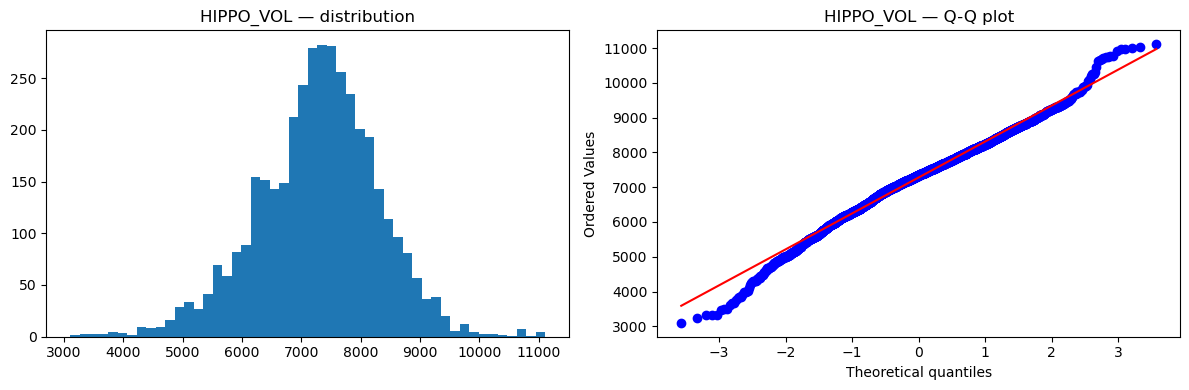

INF_LAT_VENT: Shapiro p=0.0000 | skew=2.489


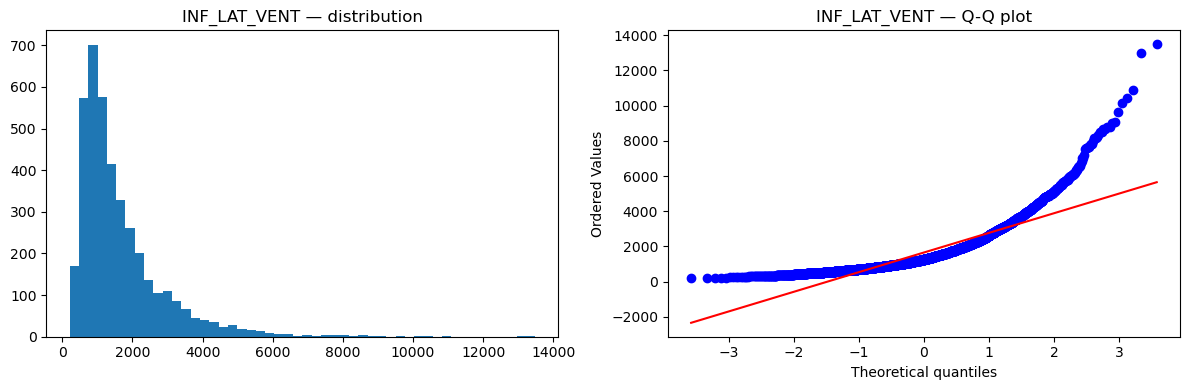

In [60]:
from scipy import stats
import matplotlib.pyplot as plt
# Check before any transformation
for target in ['HIPPO_VOL', 'INF_LAT_VENT']:
    data = df[target].dropna()
    _, p = stats.shapiro(data.sample(min(5000, len(data)), random_state=42))
    skew = stats.skew(data)
    print(f"{target}: Shapiro p={p:.4f} | skew={skew:.3f}")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(data, bins=50)
    axes[0].set_title(f'{target} — distribution')
    stats.probplot(data, plot=axes[1])
    axes[1].set_title(f'{target} — Q-Q plot')
    plt.tight_layout()
    plt.show()

In [61]:
# ============================================================
# STEP 6: Log-transform skewed targets
# ============================================================
# Check before
for target in ['HIPPO_VOL', 'INF_LAT_VENT']:
    skew = stats.skew(df[target].dropna())
    print(f"Before — {target}: skew={skew:.3f}")

df['INF_LAT_VENT'] = np.log(df['INF_LAT_VENT'])

# Check after
for target in ['HIPPO_VOL', 'INF_LAT_VENT']:
    skew = stats.skew(df[target].dropna())
    print(f"After  — {target}: skew={skew:.3f}")

Before — HIPPO_VOL: skew=-0.264
Before — INF_LAT_VENT: skew=2.489
After  — HIPPO_VOL: skew=-0.264
After  — INF_LAT_VENT: skew=0.282


HIPPO_VOL: Shapiro p=0.0000 | skew=-0.264


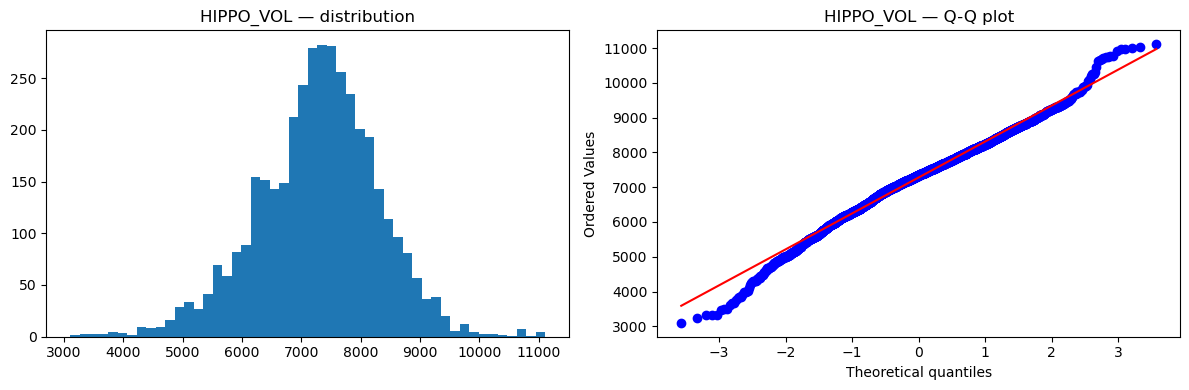

INF_LAT_VENT: Shapiro p=0.0000 | skew=0.282


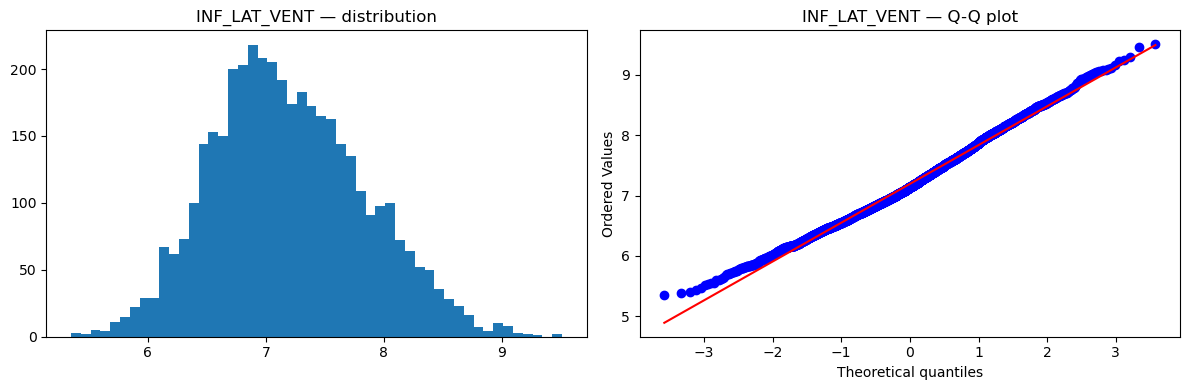

In [62]:
# Check before any transformation
for target in ['HIPPO_VOL', 'INF_LAT_VENT']:
    data = df[target].dropna()
    _, p = stats.shapiro(data.sample(min(5000, len(data)), random_state=42))
    skew = stats.skew(data)
    print(f"{target}: Shapiro p={p:.4f} | skew={skew:.3f}")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(data, bins=50)
    axes[0].set_title(f'{target} — distribution')
    stats.probplot(data, plot=axes[1])
    axes[1].set_title(f'{target} — Q-Q plot')
    plt.tight_layout()
    plt.show()

In [63]:
# ============================================================
# STEP 8: CN Selection
# ============================================================
def is_stable_cn(dx_list):
    dx_clean = [x for x in dx_list if not pd.isna(x)]
    if len(dx_clean) == 0:
        return False
    return all(x == 1 for x in dx_clean) and dx_clean[-1] == 1

cn = df[
    (df['DXHISTORY'].apply(is_stable_cn))
].copy()

print(f"Stable CN: {len(cn)} scans, {cn['RID'].nunique()} patients")
print(f"Age range: {cn['AGE'].min():.1f} - {cn['AGE'].max():.1f}")

Stable CN: 1644 scans, 681 patients
Age range: 50.8 - 104.0


In [64]:
# ============================================================
# STEP 9: TRAIN NORMATIVE MODELS — COMPREHENSIVE COMPARISON
# ============================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# --- Targets and predictors ---
TARGETS = ['HIPPO_VOL', 'INF_LAT_VENT']
INVERTED = ['INF_LAT_VENT']
PREDICTOR_COLS = ['AGE', 'PTGENDER', 'PTEDUCAT', 'ICV_VOL']

# --- Prepare CN data ---
cn_clean = cn.dropna(subset=PREDICTOR_COLS + TARGETS).copy()

# Patient-level split
from sklearn.model_selection import train_test_split
cn_rids = cn_clean['RID'].unique()
train_rids, test_rids = train_test_split(cn_rids, test_size=0.2, random_state=42)

cn_train = cn_clean[cn_clean['RID'].isin(train_rids)]
cn_test  = cn_clean[cn_clean['RID'].isin(test_rids)]

X_train = cn_train[PREDICTOR_COLS].values
X_test  = cn_test[PREDICTOR_COLS].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"CN train: {len(cn_train)} scans from {len(train_rids)} patients")
print(f"CN test:  {len(cn_test)} scans from {len(test_rids)} patients")

CN train: 1236 scans from 526 patients
CN test:  363 scans from 132 patients


In [65]:
# ============================================================
# DEFINE ALL MODELS WITH ANTI-OVERFITTING CONFIGURATIONS
# ============================================================

def get_model_configs():
    """Returns dict of {name: (model_or_pipeline, param_grid, needs_scaling)}"""
    return {
        # --- Linear models (no overfitting risk) ---
        'LR': (
            LinearRegression(),
            {},  # no params
            False
        ),
        'Ridge': (
            Ridge(),
            {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
            False
        ),
        'Lasso': (
            Lasso(max_iter=1000),
            {'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1]},
            False
        ),
        'ElasticNet': (
            ElasticNet(max_iter=1000),
            {'alpha': [0.0001, 0.001, 0.01, 0.1, 1],
             'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
            False
        ),

        # --- Tree models (constrained to prevent overfitting) ---
        'RF': (
            RandomForestRegressor(random_state=42),
            {'n_estimators': [50, 100, 200],
             'max_depth': [3, 5, 7, 10],
             'min_samples_leaf': [20, 50, 75],
             'max_features': ['sqrt', 1.0]},
            False
        ),
        'XGB': (
            XGBRegressor(random_state=42, verbosity=0),
            {'n_estimators': [50, 100, 200],
             'max_depth': [3, 5, 7],
             'min_child_weight': [20, 50],
             'learning_rate': [0.01, 0.1],
             'reg_alpha': [0, 0.1, 1],        # L1 regularization
             'reg_lambda': [1, 5, 10],         # L2 regularization
             'subsample': [0.7, 1.0],    # row subsampling
             'colsample_bytree': [0.5, 1.0]},  # feature subsampling
            False
        ),
        'GBR': (
            GradientBoostingRegressor(random_state=42),
            {'n_estimators': [50, 100, 200],
             'max_depth': [3, 5, 7],
             'min_samples_leaf': [20, 50, 100],
             'learning_rate': [0.01, 0.05, 0.1],
             'subsample': [0.7, 0.8, 1.0]},
            False
        ),

        # --- SVM (with built-in scaling) ---
        'SVM_RBF': (
            Pipeline([('scaler', StandardScaler()), ('svr', SVR())]),
            {'svr__C': [0.1, 1, 10],
             'svr__kernel': ['rbf'],
             'svr__epsilon': [0.001, 0.01, 0.1],
             'svr__gamma': ['scale', 'auto']},
            False  # scaling is inside pipeline
        ),
        'SVM_Linear': (
            Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='linear'))]),
            {'svr__C': [0.01, 0.1, 1, 10, 100],
             'svr__epsilon': [0.001, 0.01, 0.1]},
            False
        ),
    }

print(f"Models to train: {list(get_model_configs().keys())}")
print(f"Targets: {TARGETS}")

Models to train: ['LR', 'Ridge', 'Lasso', 'ElasticNet', 'RF', 'XGB', 'GBR', 'SVM_RBF', 'SVM_Linear']
Targets: ['HIPPO_VOL', 'INF_LAT_VENT']


In [66]:
# ============================================================
# TRAIN ALL MODELS FOR ALL TARGETS
# ============================================================
from scipy import stats

all_models = {}
all_results = []

for target in TARGETS:
    print(f"\n{'━'*65}")
    print(f"  {target}")
    print(f"{'━'*65}")

    y_train = cn_train[target].values
    y_test  = cn_test[target].values

    models = {}

    for name, (model, param_grid, needs_scaling) in get_model_configs().items():
        X_tr = X_train_s if needs_scaling else X_train
        X_te = X_test_s  if needs_scaling else X_test

        if param_grid:
            gs = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)
            gs.fit(X_tr, y_train)
            best_model = gs.best_estimator_
            best_params = gs.best_params_
        else:
            model.fit(X_tr, y_train)
            best_model = model
            best_params = {}

        models[name] = best_model

        y_pred_tr = best_model.predict(X_tr)
        y_pred_te = best_model.predict(X_te)

        r2_tr    = r2_score(y_train, y_pred_tr)
        r2_te    = r2_score(y_test, y_pred_te)
        rmse_te  = np.sqrt(mean_squared_error(y_test, y_pred_te))
        gap      = r2_tr - r2_te

        resid_te = y_test - y_pred_te
        _, normality_p = stats.shapiro(resid_te)

        all_results.append({
            'target': target, 'model': name,
            'R2_train': r2_tr, 'R2_test': r2_te,
            'RMSE_test': rmse_te, 'Overfit_gap': gap,
            'Normality_p': normality_p,
            'params': str(best_params)
        })

        status = '✓' if gap < 0.15 else '⚠ overfit' if gap < 0.3 else '✗ BAD'
        params_short = ', '.join(f'{k.split("__")[-1]}={v}' for k, v in best_params.items()) if best_params else 'default'
        print(f"  {name:12s} R²: {r2_tr:.4f}→{r2_te:.4f} (gap={gap:.3f}) RMSE={rmse_te:.2f} norm_p={normality_p:.3f} {status:12s} | {params_short}")

    all_models[target] = models

print(f"\n{'━'*65}")
print("✓ All classical models trained.")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  HIPPO_VOL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LR           R²: 0.2881→0.2934 (gap=-0.005) RMSE=740.57 norm_p=0.920 ✓            | default
  Ridge        R²: 0.2880→0.2975 (gap=-0.010) RMSE=738.45 norm_p=0.921 ✓            | alpha=10
  Lasso        R²: 0.2881→0.2934 (gap=-0.005) RMSE=740.57 norm_p=0.920 ✓            | alpha=1e-05
  ElasticNet   R²: 0.2860→0.3114 (gap=-0.025) RMSE=731.07 norm_p=0.889 ✓            | alpha=0.1, l1_ratio=0.5
  RF           R²: 0.4577→0.2481 (gap=0.210) RMSE=763.96 norm_p=0.789 ⚠ overfit    | max_depth=7, max_features=sqrt, min_samples_leaf=20, n_estimators=200
  XGB          R²: 0.4440→0.2660 (gap=0.178) RMSE=754.83 norm_p=0.428 ⚠ overfit    | colsample_bytree=1.0, learning_rate=0.1, max_depth=3, min_child_weight=50, n_estimators=50, reg_alpha=1, reg_lambda=10, subsample=0.7
  GBR          R²: 0.4550→0.2674 (gap=0.188) RMSE=754.11 norm_p=0.679 ⚠ overfit    |

In [67]:
# ============================================================
# TRAIN ANN ARCHITECTURES (with proper anti-overfitting)
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization,
                                      Input, Add, LeakyReLU, GaussianNoise)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from scipy import stats

tf.random.set_seed(42)

def build_ann_configs(input_dim):
    """All ANN architectures with regularization."""
    configs = {}

    # 1. Simple MLP (minimal)
    configs['ANN_Simple'] = Sequential([
        Dense(16, activation='relu', input_dim=input_dim, kernel_regularizer=l2(0.01)),
        Dropout(0.3),
        Dense(8, activation='relu', kernel_regularizer=l2(0.01)),
        Dense(1)
    ])

    # 2. Deep + BatchNorm + heavy dropout
    configs['ANN_Deep'] = Sequential([
        Dense(32, input_dim=input_dim, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        LeakyReLU(0.1),
        Dropout(0.4),
        Dense(16, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        LeakyReLU(0.1),
        Dropout(0.3),
        Dense(8, activation='relu'),
        Dense(1)
    ])

    # 3. Wide & Shallow (few layers, more neurons)
    configs['ANN_Wide'] = Sequential([
        Dense(64, activation='relu', input_dim=input_dim, kernel_regularizer=l2(0.01)),
        Dropout(0.4),
        Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.3),
        Dense(1)
    ])

    # 4. Bottleneck (compress then predict)
    configs['ANN_Bottle'] = Sequential([
        Dense(16, activation='relu', input_dim=input_dim, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(4, activation='relu', kernel_regularizer=l2(0.01)),  # bottleneck
        BatchNormalization(),
        Dense(16, activation='relu'),
        Dense(1)
    ])

    # 5. Noisy input (regularization via input noise)
    inp = Input(shape=(input_dim,))
    x = GaussianNoise(0.1)(inp)
    x = Dense(32, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(16, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.2)(x)
    out = Dense(1)(x)
    configs['ANN_Noisy'] = Model(inp, out)

    # 6. ResNet (skip connections)
    inp = Input(shape=(input_dim,))
    x = Dense(16, activation='relu', kernel_regularizer=l2(0.01))(inp)
    x = BatchNormalization()(x)
    shortcut = x
    x = Dense(16, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(16, kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Add()([x, shortcut])
    x = LeakyReLU(0.1)(x)
    x = Dense(8, activation='relu')(x)
    out = Dense(1)(x)
    configs['ANN_ResNet'] = Model(inp, out)

    # 7. Tiny (deliberately underpowered — baseline)
    configs['ANN_Tiny'] = Sequential([
        Dense(4, activation='relu', input_dim=input_dim),
        Dense(1)
    ])

    return configs

# --- Train all ANNs ---
callbacks = [
    EarlyStopping(patience=30, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(patience=15, factor=0.5, monitor='val_loss', min_lr=1e-6)
]

for target in TARGETS:
    print(f"\n{'━'*65}")
    print(f"  ANNs for: {target}")
    print(f"{'━'*65}")

    y_train = cn_train[target].values
    y_test  = cn_test[target].values

    # Scale target for stable training
    y_scaler = StandardScaler()
    y_train_sc = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_test_sc  = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

    ann_configs = build_ann_configs(len(PREDICTOR_COLS))

    for ann_name, ann_model in ann_configs.items():
        tf.random.set_seed(42)

        ann_model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
        history = ann_model.fit(
            X_train_s, y_train_sc,
            validation_data=(X_test_s, y_test_sc),
            epochs=500, batch_size=32,
            callbacks=callbacks, verbose=0
        )

        y_pred_tr = y_scaler.inverse_transform(ann_model.predict(X_train_s, verbose=0)).flatten()
        y_pred_te = y_scaler.inverse_transform(ann_model.predict(X_test_s, verbose=0)).flatten()

        r2_tr   = r2_score(y_train, y_pred_tr)
        r2_te   = r2_score(y_test, y_pred_te)
        rmse_te = np.sqrt(mean_squared_error(y_test, y_pred_te))
        gap     = r2_tr - r2_te
        epochs_used = len(history.history['loss'])

        resid_te = y_test - y_pred_te
        _, normality_p = stats.shapiro(resid_te)

        all_models[target][ann_name] = {'model': ann_model, 'y_scaler': y_scaler}
        all_results.append({
            'target': target, 'model': ann_name,
            'R2_train': r2_tr, 'R2_test': r2_te,
            'RMSE_test': rmse_te, 'Overfit_gap': gap,
            'Normality_p': normality_p,
            'params': f'epochs={epochs_used}'
        })

        status = '✓' if gap < 0.15 else '⚠ overfit' if gap < 0.3 else '✗ BAD'
        print(f"  {ann_name:12s} R²: {r2_tr:.4f}→{r2_te:.4f} (gap={gap:.3f}) RMSE={rmse_te:.2f} norm_p={normality_p:.3f} {status} | epochs={epochs_used}")

print(f"\n{'━'*65}")
print("✓ All ANN models trained.")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ANNs for: HIPPO_VOL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ANN_Simple   R²: 0.3889→0.2789 (gap=0.110) RMSE=748.14 norm_p=0.533 ✓ | epochs=207
  ANN_Deep     R²: 0.0852→0.0719 (gap=0.013) RMSE=848.76 norm_p=0.023 ✓ | epochs=30
  ANN_Wide     R²: 0.2757→0.2291 (gap=0.047) RMSE=773.57 norm_p=0.086 ✓ | epochs=30
  ANN_Bottle   R²: 0.0269→-0.0051 (gap=0.032) RMSE=883.26 norm_p=0.018 ✓ | epochs=30
  ANN_Noisy    R²: -0.0616→-0.0728 (gap=0.011) RMSE=912.52 norm_p=0.005 ✓ | epochs=30
  ANN_ResNet   R²: 0.0522→0.0857 (gap=-0.034) RMSE=842.43 norm_p=0.016 ✓ | epochs=30
  ANN_Tiny     R²: 0.2181→0.3364 (gap=-0.118) RMSE=717.69 norm_p=0.312 ✓ | epochs=41

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ANNs for: INF_LAT_VENT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ANN_Simple   R²: 0.2555→0.2439 (gap=0.012) RMSE=0.44 norm_p=0.015 ✓ | epochs=30
  ANN_Deep 

In [68]:
# ============================================================
# FULL COMPARISON TABLE
# ============================================================
results_df = pd.DataFrame(all_results)
results_df = results_df.drop_duplicates(subset=['model', 'target'], keep='last')

# R² test pivot
print("R² (test) — all models × all targets:\n")
pivot_r2 = results_df.pivot_table(index='model', columns='target', values='R2_test')
pivot_r2['MEAN'] = pivot_r2.mean(axis=1)
pivot_r2 = pivot_r2.sort_values('MEAN', ascending=False)
print(pivot_r2.round(4).to_string())

# Overfit gap pivot
print("\n\nOverfit gap (R²_train - R²_test) — smaller is better:\n")
pivot_gap = results_df.pivot_table(index='model', columns='target', values='Overfit_gap')
pivot_gap['MEAN'] = pivot_gap.mean(axis=1)
pivot_gap = pivot_gap.reindex(pivot_r2.index)
print(pivot_gap.round(4).to_string())

# RMSE pivot
print("\n\nRMSE (test) — smaller is better:\n")
pivot_rmse = results_df.pivot_table(index='model', columns='target', values='RMSE_test')
pivot_rmse['MEAN'] = pivot_rmse.mean(axis=1)
pivot_rmse = pivot_rmse.reindex(pivot_r2.index)
print(pivot_rmse.round(2).to_string())

# Normality pivot
print("\n\nResiduals normality p-value (>0.05 = normal):\n")
pivot_norm = results_df.pivot_table(index='model', columns='target', values='Normality_p')
pivot_norm = pivot_norm.reindex(pivot_r2.index)
print(pivot_norm.round(4).to_string())

# Best model per target
print("\n\nBest model per target (highest R² test):")
for target in TARGETS:
    sub = results_df[results_df['target'] == target]
    best = sub.loc[sub['R2_test'].idxmax()]
    print(f"  {target:17s} → {best['model']:12s} R²={best['R2_test']:.4f} | RMSE={best['RMSE_test']:.2f} | gap={best['Overfit_gap']:.3f} | norm_p={best['Normality_p']:.3f}")

# Overall winner
print(f"\nOverall best (mean R² test): {pivot_r2['MEAN'].idxmax()} "
      f"(R²={pivot_r2['MEAN'].max():.4f})")

R² (test) — all models × all targets:

target      HIPPO_VOL  INF_LAT_VENT    MEAN
model                                      
SVM_Linear     0.3105        0.3567  0.3336
ANN_Tiny       0.3364        0.3235  0.3300
ElasticNet     0.3114        0.3458  0.3286
LR             0.2934        0.3496  0.3215
Ridge          0.2975        0.3433  0.3204
Lasso          0.2934        0.3414  0.3174
ANN_Wide       0.2291        0.3289  0.2790
XGB            0.2660        0.2858  0.2759
GBR            0.2674        0.2771  0.2723
RF             0.2481        0.2803  0.2642
ANN_Simple     0.2789        0.2439  0.2614
SVM_RBF        0.1748        0.2810  0.2279
ANN_ResNet     0.0857        0.0960  0.0909
ANN_Deep       0.0719        0.0392  0.0556
ANN_Noisy     -0.0728        0.0856  0.0064
ANN_Bottle    -0.0051        0.0108  0.0029


Overfit gap (R²_train - R²_test) — smaller is better:

target      HIPPO_VOL  INF_LAT_VENT    MEAN
model                                      
SVM_Linear    -0.0296   

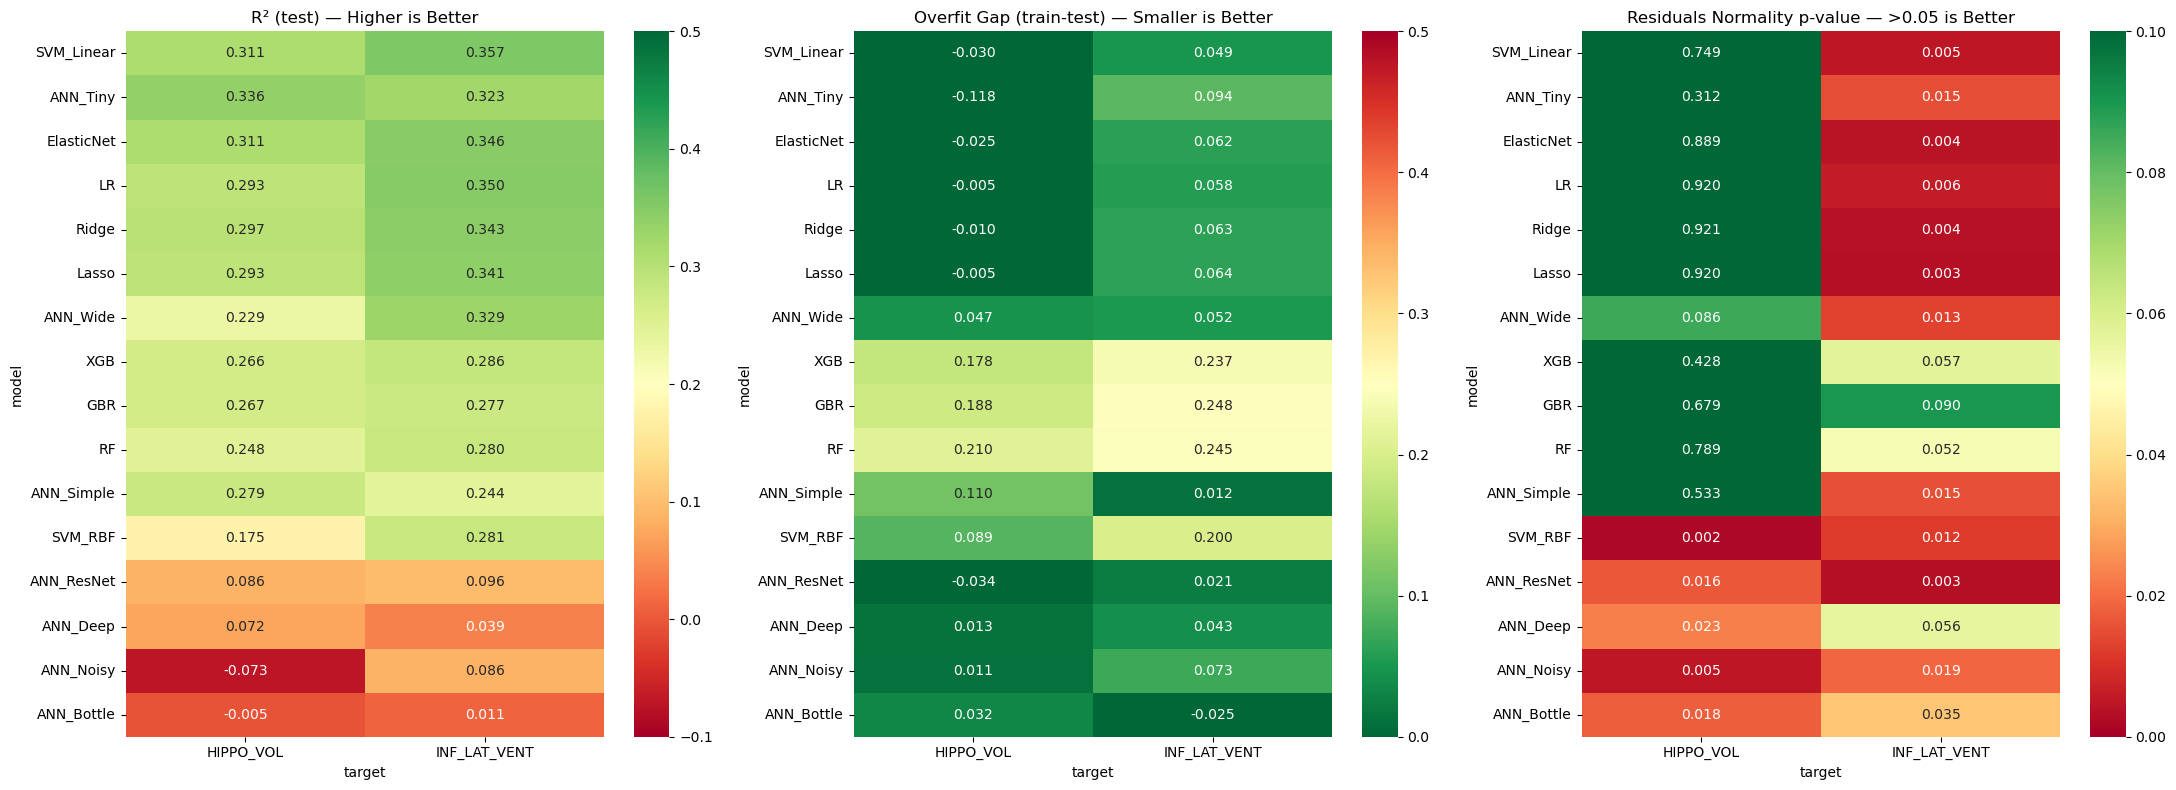

In [72]:
# ============================================================
# VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# 1. R² test heatmap
sns.heatmap(pivot_r2.drop(columns='MEAN'), annot=True, fmt='.3f',
            cmap='RdYlGn', ax=axes[0], vmin=-0.1, vmax=0.5, center=0.2)
axes[0].set_title('R² (test) — Higher is Better')

# 2. Overfit gap heatmap
sns.heatmap(pivot_gap.drop(columns='MEAN'), annot=True, fmt='.3f',
            cmap='RdYlGn_r', ax=axes[1], vmin=0, vmax=0.5)
axes[1].set_title('Overfit Gap (train-test) — Smaller is Better')

# 3. Normality p-value heatmap
sns.heatmap(pivot_norm, annot=True, fmt='.3f',
            cmap='RdYlGn', ax=axes[2], vmin=0, vmax=0.1, center=0.05)
axes[2].set_title('Residuals Normality p-value — >0.05 is Better')

plt.tight_layout()
plt.show()

In [109]:
# ============================================================
# STEP 10: MAJORITY VOTING PER REGION → SCALE LABELING
# ============================================================

TOP_K = 5

TOP_MODELS = {}
for target in TARGETS:
    sub = results_df[results_df['target'] == target].copy()
    
    # Filter: no overfitting
    sub = sub[sub['Overfit_gap'] < 0.15]
    
    # For HIPPO: require normality
    if target not in INVERTED:
        sub = sub[sub['Normality_p'] > 0.05]
    
    # Sort by R² test
    sub = sub.sort_values('R2_test', ascending=False)
    
    TOP_MODELS[target] = sub.head(TOP_K)['model'].tolist()
    print(f"{target}: {TOP_MODELS[target]}")

HIPPO_VOL: ['ANN_Tiny', 'ElasticNet', 'SVM_Linear', 'Ridge', 'Lasso']
INF_LAT_VENT: ['SVM_Linear', 'LR', 'ElasticNet', 'Ridge', 'Lasso']


In [110]:
print(df['INF_LAT_VENT'].describe())  # should be ~5-9 range (log scale)
print(cn_clean['INF_LAT_VENT'].describe())  # same scale?

count    4007.000000
mean        7.194681
std         0.644883
min         5.348059
25%         6.736611
50%         7.141562
75%         7.620460
max         9.509177
Name: INF_LAT_VENT, dtype: float64
count    1599.000000
mean        6.944281
std         0.528616
min         5.467216
25%         6.581886
50%         6.912544
75%         7.287321
max         8.543718
Name: INF_LAT_VENT, dtype: float64


In [113]:
from scipy.stats import median_abs_deviation
# ============================================================
# COMPUTE Z-SCORES FOR ALL TOP MODELS PER TARGET
# ============================================================

df_eval = df.dropna(subset=PREDICTOR_COLS + TARGETS).copy()
X_all = df_eval[PREDICTOR_COLS].values
X_all_s = scaler.transform(X_all)
cn_mask = df_eval['DIAGNOSIS'].values == 1

def predict_with_model(model_obj, X, X_scaled):
    if isinstance(model_obj, dict) and 'model' in model_obj:
        pred_sc = model_obj['model'].predict(X_scaled, verbose=0).flatten()
        return model_obj['y_scaler'].inverse_transform(pred_sc.reshape(-1, 1)).flatten()
    else:
        return model_obj.predict(X)

# Store per-region, per-model binary labels
region_votes = {}  # {target: DataFrame with columns = model names, values = 0/1}

for target in TARGETS:
    votes = pd.DataFrame(index=df_eval.index)
    actual = df_eval[target].values

    for model_name in TOP_MODELS[target]:
        model_obj = all_models[target][model_name]
        pred = predict_with_model(model_obj, X_all, X_all_s)
        resid = actual - pred

        cn_resid = resid[cn_mask]

        if target in INVERTED:
            # Robust Z-score for non-normal residuals
            mad = median_abs_deviation(cn_resid)
            z = (resid - np.median(cn_resid)) / (1.4826 * mad)
            z = -z  # flip: enlargement = atrophy
        else:
            z = (resid - cn_resid.mean()) / cn_resid.std()

        votes[model_name] = (z < -1.654).astype(int)

    region_votes[target] = votes


print("Binary votes computed for all regions and models.")

Binary votes computed for all regions and models.


In [114]:
# ============================================================
# MAJORITY VOTING: 3/5 models must agree → atrophic
# ============================================================

MAJORITY_THRESHOLD = TOP_K // 2 + 1  # 3 out of 5

df_labels = df_eval[['RID', 'VISCODE', 'VISCODE2', 'DIAGNOSIS', 'AGE', 'PTGENDER']].copy()

for target in TARGETS:
    votes = region_votes[target]
    vote_sum = votes.sum(axis=1)
    df_labels[f'{target}_VOTES'] = vote_sum
    df_labels[f'{target}_ATROPHY'] = (vote_sum >= MAJORITY_THRESHOLD).astype(int)

# Show voting distribution per region
print(f"Majority threshold: {MAJORITY_THRESHOLD}/{TOP_K} models must agree\n")
for target in TARGETS:
    vc = df_labels[f'{target}_VOTES'].value_counts().sort_index()
    atrophy_rate = df_labels[f'{target}_ATROPHY'].mean() * 100
    print(f"{target:20s} → {atrophy_rate:5.1f}% atrophic | vote distribution: {vc.to_dict()}")

Majority threshold: 3/5 models must agree

HIPPO_VOL            →  15.4% atrophic | vote distribution: {0: 3189, 1: 84, 2: 17, 3: 14, 4: 66, 5: 521}
INF_LAT_VENT         →  14.2% atrophic | vote distribution: {0: 3320, 1: 11, 2: 9, 3: 12, 4: 17, 5: 522}


In [115]:
# ============================================================
# AGREEMENT STRENGTH: unanimous vs bare majority
# ============================================================

for target in TARGETS:
    votes = df_labels[f'{target}_VOTES']
    unanimous_healthy = (votes == 0).sum()
    unanimous_atrophic = (votes == TOP_K).sum()
    bare_majority = ((votes == MAJORITY_THRESHOLD) | (votes == TOP_K - MAJORITY_THRESHOLD)).sum()
    
    print(f"{target:20s} → unanimous healthy: {unanimous_healthy}, "
          f"unanimous atrophic: {unanimous_atrophic}, "
          f"borderline (bare majority): {bare_majority}")

HIPPO_VOL            → unanimous healthy: 3189, unanimous atrophic: 521, borderline (bare majority): 31
INF_LAT_VENT         → unanimous healthy: 3320, unanimous atrophic: 522, borderline (bare majority): 21


In [116]:
# ============================================================
# COMBINE REGIONS INTO CLINICAL SCALES
# ============================================================
# MTA (Scheltens): atrophic if ANY of hippo, erc, temporal horn is atrophic
# GCA (Pasquier):  atrophic if cortical GM is atrophic
# Koedam:          atrophic if ANY posterior region is atrophic

MTA_TARGETS = ['HIPPO_VOL', 'INF_LAT_VENT']
df_labels['MTA_ATROPHY'] = df_labels[[f'{t}_ATROPHY' for t in MTA_TARGETS]].max(axis=1)

# Report
print(f"\n{'='*65}")
print(f"  BINARY SCALE LABELS — Majority Voting ({MAJORITY_THRESHOLD}/{TOP_K})")
print(f"{'='*65}")

binary_labels = {0: 'Healthy', 1: 'Atrophic'}
for dx in sorted(df_labels['DIAGNOSIS'].dropna().unique()):
    sub = df_labels[df_labels['DIAGNOSIS'] == dx]
    dx_label = {1:'CN', 2:'MCI', 3:'AD'}.get(int(dx), f'DX={int(dx)}')
    print(f"\n  {dx_label} (n={len(sub)})")
    for scale in ['MTA_ATROPHY']:
        counts = sub[scale].value_counts().sort_index()
        parts = [f"{binary_labels[s]}: {counts.get(s,0)} ({100*counts.get(s,0)/len(sub):.1f}%)" for s in [0,1]]
        print(f"    {scale:16s} → {' | '.join(parts)}")


  BINARY SCALE LABELS — Majority Voting (3/5)

  CN (n=2023)
    MTA_ATROPHY      → Healthy: 1798 (88.9%) | Atrophic: 225 (11.1%)

  MCI (n=1476)
    MTA_ATROPHY      → Healthy: 1035 (70.1%) | Atrophic: 441 (29.9%)

  AD (n=336)
    MTA_ATROPHY      → Healthy: 97 (28.9%) | Atrophic: 239 (71.1%)


In [118]:
# ============================================================
# MTA ORDINAL SCORE (adapted, 2-feature version)
# ============================================================

# Precompute Z-scores per patient (mean across top models)
for target in TARGETS:
    actual = df_eval[target].values
    z_scores = []
    
    for model_name in TOP_MODELS[target]:
        model_obj = all_models[target][model_name]
        pred = predict_with_model(model_obj, X_all, X_all_s)
        resid = actual - pred
        cn_resid = resid[cn_mask]
        
        if target in INVERTED:
            mad = median_abs_deviation(cn_resid)
            z = (resid - np.median(cn_resid)) / (1.4826 * mad)
            z = -z
        else:
            z = (resid - cn_resid.mean()) / cn_resid.std()
        
        z_scores.append(z)
    
    df_labels[f'{target}_Z'] = np.mean(z_scores, axis=0)

# ============================================================
# Ordinal scoring
# ============================================================
def mta_score(row):
    hz = row['HIPPO_VOL_Z']
    vz = row['INF_LAT_VENT_Z']
    
    hippo_severe   = hz < -2.0
    hippo_atrophic = hz < -1.654
    vent_atrophic  = vz < -1.654

    if hippo_severe and vent_atrophic:
        return 4
    elif hippo_atrophic and vent_atrophic:
        return 3
    elif hippo_atrophic or vent_atrophic:
        return 2
    else:
        return 0

df_labels['MTA_SCORE'] = df_labels.apply(mta_score, axis=1)

# Report
print(f"\n{'='*65}")
print(f"  MTA ORDINAL SCORE DISTRIBUTION")
print(f"{'='*65}")
for dx in sorted(df_labels['DIAGNOSIS'].dropna().unique()):
    sub = df_labels[df_labels['DIAGNOSIS'] == dx]
    dx_label = {1:'CN', 2:'MCI', 3:'AD'}.get(int(dx), f'DX={int(dx)}')
    counts = sub['MTA_SCORE'].value_counts().sort_index()
    print(f"\n  {dx_label} (n={len(sub)})")
    for score, count in counts.items():
        print(f"    Score {score}: {count} ({100*count/len(sub):.1f}%)")


  MTA ORDINAL SCORE DISTRIBUTION

  CN (n=2023)
    Score 0: 1796 (88.8%)
    Score 2: 215 (10.6%)
    Score 3: 4 (0.2%)
    Score 4: 8 (0.4%)

  MCI (n=1476)
    Score 0: 1040 (70.5%)
    Score 2: 335 (22.7%)
    Score 3: 22 (1.5%)
    Score 4: 79 (5.4%)

  AD (n=336)
    Score 0: 98 (29.2%)
    Score 2: 112 (33.3%)
    Score 3: 14 (4.2%)
    Score 4: 112 (33.3%)


In [122]:
df = df.drop(columns=['MTA_ATROPHY', 'MTA_SCORE'], errors='ignore')

df = df.merge(df_labels[['RID', 'VISCODE2', 'MTA_ATROPHY', 'MTA_SCORE']], 
              on=['RID', 'VISCODE2'], how='left')

In [123]:
for col in ['MTA_ATROPHY', 'MTA_SCORE']:
    print(f"\n{col} distribution:")
    for dx in sorted(df['DIAGNOSIS'].dropna().unique()):
        sub = df[df['DIAGNOSIS'] == dx]
        dx_label = {1:'CN', 2:'MCI', 3:'AD'}.get(int(dx), f'DX={int(dx)}')
        counts = sub[col].value_counts().sort_index()
        print(f"  {dx_label} (n={len(sub)}): {counts.to_dict()}")


MTA_ATROPHY distribution:
  CN (n=2075): {0.0: 1798, 1.0: 225}
  MCI (n=1531): {0.0: 1035, 1.0: 441}
  AD (n=369): {0.0: 97, 1.0: 239}

MTA_SCORE distribution:
  CN (n=2075): {0.0: 1796, 2.0: 215, 3.0: 4, 4.0: 8}
  MCI (n=1531): {0.0: 1040, 2.0: 335, 3.0: 22, 4.0: 79}
  AD (n=369): {0.0: 98, 2.0: 112, 3.0: 14, 4.0: 112}


In [124]:
print("MTA_ATROPHY global:")
print(df['MTA_ATROPHY'].value_counts().sort_index())

print("\nMTA_SCORE global:")
print(df['MTA_SCORE'].value_counts().sort_index())

MTA_ATROPHY global:
MTA_ATROPHY
0.0    2976
1.0     915
Name: count, dtype: int64

MTA_SCORE global:
MTA_SCORE
0.0    2978
2.0     674
3.0      40
4.0     199
Name: count, dtype: int64


In [125]:
# ============================================================
# VALIDATION: CN vs AD separation
# ============================================================
cn = df_labels[df_labels['DIAGNOSIS'] == 1]
ad = df_labels[df_labels['DIAGNOSIS'] == 3]
mci = df_labels[df_labels['DIAGNOSIS'] == 2]

print(f"{'='*65}")
print(f"  VALIDATION — MTA Labels")
print(f"{'='*65}")

print(f"\n  Binary MTA_ATROPHY (expect CN~5%, AD>>5%):")
print(f"    CN  atrophy rate: {cn['MTA_ATROPHY'].mean()*100:.1f}%")
print(f"    MCI atrophy rate: {mci['MTA_ATROPHY'].mean()*100:.1f}%")
print(f"    AD  atrophy rate: {ad['MTA_ATROPHY'].mean()*100:.1f}%")

print(f"\n  MTA_SCORE mean (expect AD > MCI > CN):")
print(f"    CN  mean score: {cn['MTA_SCORE'].mean():.3f}")
print(f"    MCI mean score: {mci['MTA_SCORE'].mean():.3f}")
print(f"    AD  mean score: {ad['MTA_SCORE'].mean():.3f}")
print(f"    AD-CN separation: {ad['MTA_SCORE'].mean() - cn['MTA_SCORE'].mean():.3f}")

print(f"\n  Per-region atrophy rates:")
for target in TARGETS:
    cn_rate  = cn[f'{target}_ATROPHY'].mean() * 100
    mci_rate = mci[f'{target}_ATROPHY'].mean() * 100
    ad_rate  = ad[f'{target}_ATROPHY'].mean() * 100
    print(f"    {target:20s} → CN: {cn_rate:5.1f}% | MCI: {mci_rate:5.1f}% | AD: {ad_rate:5.1f}%")

  VALIDATION — MTA Labels

  Binary MTA_ATROPHY (expect CN~5%, AD>>5%):
    CN  atrophy rate: 11.1%
    MCI atrophy rate: 29.9%
    AD  atrophy rate: 71.1%

  MTA_SCORE mean (expect AD > MCI > CN):
    CN  mean score: 0.234
    MCI mean score: 0.713
    AD  mean score: 2.125
    AD-CN separation: 1.891

  Per-region atrophy rates:
    HIPPO_VOL            → CN:   5.4% | MCI:  19.9% | AD:  56.5%
    INF_LAT_VENT         → CN:   6.3% | MCI:  16.7% | AD:  52.1%


In [126]:
# ============================================================
# SAVE BOTH TABLES
# ============================================================

df[['RID', 'VISCODE2', 'DIAGNOSIS', 'AGE', 'PTGENDER', 'PTEDUCAT', 'MTA_ATROPHY', 'MTA_SCORE']].to_csv('MTA_atrophy_labels.csv', index=False)

In [138]:
print(f"Unique RID values: {df['RID'].nunique()}")
print(f"Unique VISCODE2 values: {df['VISCODE2'].nunique()}")
print(len(df))

Unique RID values: 1396
Unique VISCODE2 values: 41
4032


In [139]:
ucsffsx7_2 = pd.read_csv("data/UCSFFSX7.csv")

In [140]:
df_copy = df.copy()

In [141]:
# Map RID → PTID
rid_to_ptid = ucsffsx7_2[['RID', 'PTID']].drop_duplicates().set_index('RID')['PTID']
df_copy['PTID'] = df_copy['RID'].map(rid_to_ptid)

print(f"PTID assigned: {df_copy['PTID'].notna().sum()} / {len(df_copy)}")
print(f"PTID missing:  {df_copy['PTID'].isna().sum()}")
print(f"Example: RID={df_copy['RID'].iloc[0]} → PTID={df_copy['PTID'].iloc[0]}")

PTID assigned: 4032 / 4032
PTID missing:  0
Example: RID=21 → PTID=011_S_0021


In [142]:
print(f"Our PTIDs: {len(df_copy['PTID'].unique())}")

Our PTIDs: 1396


In [143]:
df_copy[['PTID','RID', 'VISCODE2', 'DIAGNOSIS', 'AGE', 'PTGENDER', 'PTEDUCAT', 'MTA_ATROPHY', 'MTA_SCORE']].to_csv('MTA_atrophy_labels.csv', index=False)

In [145]:
# Map RID → PTID
rid_to_ptid = ucsffsx7_2[['RID', 'PTID']].drop_duplicates().set_index('RID')['PTID']
df_copy['PTID'] = df_copy['RID'].map(rid_to_ptid)

# Load KEYMRI
keymri = pd.read_csv("data/KEYMRI.csv")

# Filter to our PTIDs
our_ptids = df_copy['PTID'].dropna().unique()
keymri_filtered = keymri[keymri['subject_id'].isin(our_ptids)]

print(f"Our PTIDs: {len(our_ptids)}")
print(f"Matched PTIDs in KEYMRI: {keymri_filtered['subject_id'].nunique()}")
print(f"KEYMRI total rows: {len(keymri)}")
print(f"KEYMRI matching our PTIDs: {len(keymri_filtered)}")
print(f"Unique image IDs: {keymri_filtered['image_id'].nunique()}")
print(f"\nColumns: {keymri_filtered.columns.tolist()}")

Our PTIDs: 1396
Matched PTIDs in KEYMRI: 1396
KEYMRI total rows: 91167
KEYMRI matching our PTIDs: 49057
Unique image IDs: 49057

Columns: ['image_id', 'subject_id', 'image_visit', 'image_date', 'series_type', 'mri_protocol_phase', 'series_description', 'acceleration', 'acquisition_type', 'acquisition_plane', 'number_volumes', 'slices_per_volume', 'slice_thickness', 'scanner_manufacturer', 'scanner_model', 'software_version', 'magnetic_field_strength', 'receive_coil_name', 'study_instance_uid', 'series_instance_uid', 'loni_study', 'loni_series', 'loni_image']


In [146]:
skip_cols = ['image_id', 'subject_id', 'study_instance_uid', 'series_instance_uid',
             'loni_study', 'loni_series', 'loni_image']

for col in keymri_filtered.columns:
    if col in skip_cols:
        continue
    nunique = keymri_filtered[col].nunique()
    print(f"\n{'='*50}")
    print(f"  {col} — {nunique} unique values")
    print(f"{'='*50}")
    if nunique <= 30:
        print(keymri_filtered[col].value_counts().to_string())
    else:
        print(f"Top 20:")
        print(keymri_filtered[col].value_counts().head(20).to_string())

print(f"\n{'='*50}")
print(f"  Images per PTID + visit")
print(f"{'='*50}")
imgs_per_visit = keymri_filtered.groupby(['subject_id', 'image_visit']).size()
print(f"Distribution:")
print(imgs_per_visit.value_counts().sort_index().to_string())


  image_visit — 31 unique values
Top 20:
image_visit
sc        7247
y2        5329
4_sc      4851
y1        4436
4_init    3436
init      3113
v21       2718
y4        2497
4_m12     2109
v11       2056
v02       1924
v04       1689
v41       1605
v05       1503
y3        1052
v31        586
4_m24      531
m06        389
y5         331
v06        311

  image_date — 2613 unique values
Top 20:
image_date
2024-06-12    115
2025-05-15     92
2018-07-06     89
2020-07-23     85
2025-03-11     80
2024-09-16     79
2017-11-30     77
2019-08-27     76
2024-11-08     76
2019-09-17     75
2018-06-27     75
2024-10-31     75
2012-02-29     74
2018-07-16     72
2017-10-03     70
2018-08-15     70
2019-06-27     69
2018-03-14     67
2020-10-21     66
2019-09-12     66

  series_type — 15 unique values
series_type
T1w                 7118
derived             6316
ASL                 5085
FLAIR               4700
dMRI                4168
calibration         4095
T2starw             3500
T2w_HighRes

In [148]:
import pandas as pd

keymri = pd.read_csv('data/KEYMRI.csv')

# Filter keymri: T1w + 3D + 3T + Sagittal
img = keymri[
    (keymri['series_type'] == 'T1w') &
    (keymri['acquisition_type'] == '3D') &
    (keymri['acquisition_plane'] == 'Sagittal') &
    (keymri['magnetic_field_strength'] == 3.0)
].copy()

# Keep one image per patient+visit (thinnest slices first)
img = img.sort_values('slice_thickness', ascending=True)
img = img.drop_duplicates(subset=['subject_id', 'image_visit'], keep='first')

# Match image_id from keymri on PTID + EXAMDATE
df_copy['EXAMDATE'] = pd.to_datetime(df_copy['EXAMDATE']).dt.strftime('%Y-%m-%d')
img['image_date'] = pd.to_datetime(img['image_date']).dt.strftime('%Y-%m-%d')

download_set = df_copy.merge(
    img[['subject_id', 'image_date', 'image_id', 'slice_thickness']],
    left_on=['PTID', 'EXAMDATE'],
    right_on=['subject_id', 'image_date'],
    how='left'
).drop(columns=['subject_id', 'image_date'])

# Drop unmatched
download_final = download_set[download_set['image_id'].notna()].copy()
download_final['image_id'] = download_final['image_id'].astype(int)

print(f"Final: {len(download_final)} images ({download_final['image_id'].nunique()} unique)")
print(f"Healthy: {(download_final['MTA_ATROPHY']==0).sum()} | Atrophic: {(download_final['MTA_ATROPHY']==1).sum()}")
print(f"Unmatched (dropped): {len(download_set) - len(download_final)}")

download_final.to_csv('MTA_atrophy_labels_fin.csv', index=False)
print(f"\nSaved: download_set_final.csv ({len(download_final)} rows)")

Final: 3694 images (3694 unique)
Healthy: 2726 | Atrophic: 827
Unmatched (dropped): 338

Saved: download_set_final.csv (3694 rows)


In [149]:
old = pd.read_csv('data/atrophy_labels.csv')  # adjust filename
new = download_final

# Normalize
old['image_id'] = old['image_id'].astype(int)
new['image_id'] = new['image_id'].astype(int)

old_set = set(zip(old['PTID'], old['VISCODE2'], old['image_id']))
new_set = set(zip(new['PTID'], new['VISCODE2'], new['image_id']))

print(f"Old: {len(old_set)} unique (PTID, VISCODE2, image_id)")
print(f"New: {len(new_set)} unique (PTID, VISCODE2, image_id)")
print(f"Common: {len(old_set & new_set)}")
print(f"Only in old: {len(old_set - new_set)}")
print(f"Only in new: {len(new_set - old_set)}")

Old: 2404 unique (PTID, VISCODE2, image_id)
New: 3694 unique (PTID, VISCODE2, image_id)
Common: 2022
Only in old: 382
Only in new: 1672


In [150]:
common_ids = old_set & new_set

common = download_final[
    download_final.apply(lambda r: (r['PTID'], r['VISCODE2'], r['image_id']) in common_ids, axis=1)
]

print(f"Common: {len(common)}")
print(f"Healthy:  {(common['MTA_ATROPHY']==0).sum()} ({(common['MTA_ATROPHY']==0).mean()*100:.1f}%)")
print(f"Atrophic: {(common['MTA_ATROPHY']==1).sum()} ({(common['MTA_ATROPHY']==1).mean()*100:.1f}%)")

Common: 2022
Healthy:  1374 (68.0%)
Atrophic: 648 (32.0%)


In [151]:
common.to_csv('MTA_labels.csv', index=False)
print(f"Saved: download_set_common.csv ({len(common)} rows)")

Saved: download_set_common.csv (2022 rows)
